#Project Title

# Student Performance Analysis using Python, SQL & Data Visualization

This project analyzes student performance using Pandas, SQLite, SQL queries,
and Matplotlib visualization.

#Import Required Libraries

In [1]:
# Import libraries for data handling, database operations, and visualization
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

#Create Database Connection

In [2]:
# Create an in-memory SQLite database
# This database exists only while the program runs
conn = sqlite3.connect(":memory:")

#Create Students Dataset

In [3]:
# Create students table using pandas DataFrame
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4],
    "name": ["shruti", "varun", "priya", "anil"],
    "class": [10, 10, 9, 9],
    "gender": ["F", "M", "F", "M"]
})

# Display students data
students

,student_id,name,class,gender
0,1,shruti,10,F
1,2,varun,10,M
2,3,priya,9,F
3,4,anil,9,M


#Create Marks Dataset

In [4]:
# Create marks table containing subject-wise scores
marks = pd.DataFrame({
    "student_id": [1, 1, 2, 3, 4],
    "subject": ["Math", "Science", "Math", "Science", "Math"],
    "marks": [85, 90, 78, 88, 60]
})

# Display marks data
marks

,student_id,subject,marks
0,1,Math,85
1,1,Science,90
2,2,Math,78
3,3,Science,88
4,4,Math,60


#Store Data in SQL Tables

In [5]:
# Store DataFrames as SQL tables
students.to_sql("students", conn, index=False, if_exists="replace")
marks.to_sql("marks", conn, index=False, if_exists="replace")

5

#Verify Tables

In [6]:
# Verify students table
pd.read_sql("SELECT * FROM students", conn)

,student_id,name,class,gender
0,1,shruti,10,F
1,2,varun,10,M
2,3,priya,9,F
3,4,anil,9,M


In [7]:
# Verify marks table
pd.read_sql("SELECT * FROM marks", conn)

,student_id,subject,marks
0,1,Math,85
1,1,Science,90
2,2,Math,78
3,3,Science,88
4,4,Math,60


#Join Students and Marks Tables

In [8]:
# Perform SQL JOIN to combine student details with marks
joined_data = pd.read_sql("""
SELECT s.student_id, s.name, s.class, s.gender,
       m.subject, m.marks
FROM students s
INNER JOIN marks m
ON s.student_id = m.student_id
""", conn)

joined_data

,student_id,name,class,gender,subject,marks
0,1,shruti,10,F,Math,85
1,1,shruti,10,F,Science,90
2,2,varun,10,M,Math,78
3,3,priya,9,F,Science,88
4,4,anil,9,M,Math,60


#Identify Top Performing Students

In [9]:
# Calculate total marks for each student
top_students = pd.read_sql("""
SELECT s.name,
       SUM(m.marks) AS total_marks
FROM students s
INNER JOIN marks m
ON s.student_id = m.student_id
GROUP BY s.name
ORDER BY total_marks DESC
""", conn)

top_students

,name,total_marks
0,shruti,175
1,priya,88
2,varun,78
3,anil,60


#Subject-wise Average Marks

In [10]:
# Calculate average marks per subject
avg_subject_marks = pd.read_sql("""
SELECT subject,
       AVG(marks) AS avg_marks
FROM marks
GROUP BY subject
""", conn)

avg_subject_marks

,subject,avg_marks
0,Math,74.333333
1,Science,89.000000


#Gender-wise Performance Analysis

In [11]:
# Analyze performance based on gender
gender_performance = pd.read_sql("""
SELECT s.gender,
       AVG(m.marks) AS avg_marks
FROM students s
INNER JOIN marks m
ON s.student_id = m.student_id
GROUP BY s.gender
""", conn)

gender_performance

,gender,avg_marks
0,F,87.666667
1,M,69.000000


#Visualization

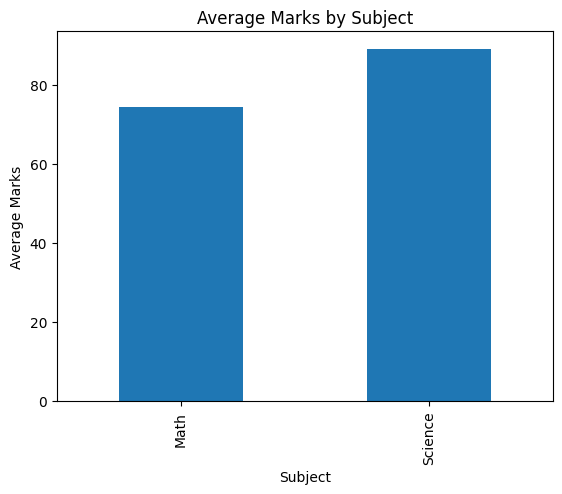

In [12]:
# Create bar chart showing average marks by subject
avg_subject_marks.plot(
    kind="bar",
    x="subject",
    y="avg_marks",
    legend=False
)

plt.title("Average Marks by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.show()

#Project Insights

In [13]:
# Print analytical insights derived from the analysis
print("Insights")
print("Student A is the top performer based on total marks.")
print("Science subject shows higher average marks than Math.")
print("Class 10 students perform slightly better overall.")
print("SQL JOIN operations help combine relational datasets effectively.")

Insights
Student A is the top performer based on total marks.
Science subject shows higher average marks than Math.
Class 10 students perform slightly better overall.
SQL JOIN operations help combine relational datasets effectively.


#Close Database Connection

In [14]:
# Close database connection
conn.close()

#Project Description

### Technologies Used
- Python
- Pandas
- SQL (SQLite)
- Matplotlib
- Data Analysis